In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import pickle
import sys
import os
from pathlib import Path

def find_experiment_directories(base_path="../results"):
    """
    Find all experiment directories that match the pattern: YYYYMMDD_HHMMSS_DATASET_*
    
    Returns:
        dict: {dataset: [list of experiment directories]}
    """
    experiment_dirs = {}
    base_path = Path(base_path)
    
    for dataset_dir in base_path.iterdir():
        if dataset_dir.is_dir():
            dataset_name = dataset_dir.name
            experiment_dirs[dataset_name] = []
            
            for exp_dir in dataset_dir.iterdir():
                if exp_dir.is_dir() and len(exp_dir.name.split('_')) >= 3:
                    # Check if it matches the pattern YYYYMMDD_HHMMSS_DATASET_*
                    parts = exp_dir.name.split('_')
                    if (len(parts[0]) == 8 and parts[0].isdigit() and 
                        len(parts[1]) == 6 and parts[1].isdigit() and
                        parts[2] == dataset_name):
                        experiment_dirs[dataset_name].append(exp_dir)
    
    return experiment_dirs

def get_latest_experiment(dataset, experiment_dirs=None, qualifier=None):
    """
    Get the latest experiment directory for a dataset.
    
    Args:
        dataset: Dataset name
        experiment_dirs: Pre-computed experiment directories (optional)
        qualifier: Optional qualifier to filter experiments (e.g., 'default', 'test')
    
    Returns:
        Path: Latest experiment directory or None if not found
    """
    if experiment_dirs is None:
        experiment_dirs = find_experiment_directories()
    
    if dataset not in experiment_dirs:
        return None
    
    # Filter by qualifier if provided
    candidates = experiment_dirs[dataset]
    if qualifier:
        candidates = [d for d in candidates if qualifier in d.name]
    
    if not candidates:
        return None
    
    # Sort by timestamp (YYYYMMDD_HHMMSS)
    candidates.sort(key=lambda x: x.name.split('_')[:2], reverse=True)
    return candidates[0]

def load_evaluation_results(dataset, subontology, split="test", experiment_dir=None, qualifier=None):
    """
    Load evaluation results from the new file format.
    
    Args:
        dataset: Dataset name (H30, ATGO, D1)
        subontology: Subontology (BPO, MFO, CCO)
        split: Split name ("test" or "val")
        experiment_dir: Specific experiment directory (optional)
        qualifier: Experiment qualifier to find latest (optional)
    
    Returns:
        dict: Loaded evaluation results
    """
    if experiment_dir is None:
        experiment_dirs = find_experiment_directories()
        experiment_dir = get_latest_experiment(dataset, experiment_dirs, qualifier)
        
    if experiment_dir is None:
        raise FileNotFoundError(f"No experiment directory found for dataset {dataset}")
    
    results_path = experiment_dir / "evaluation" / f"{split}_{subontology}" / "beprof_eval_results.pkl"
    
    if not results_path.exists():
        raise FileNotFoundError(f"Evaluation results not found: {results_path}")
    
    with open(results_path, 'rb') as f:
        results = pickle.load(f)
    
    return results

def load_predictions(dataset, subontology, split="test", experiment_dir=None, qualifier=None, return_pickle=False):
    """
    Load predictions from the new file format.
    
    Args:
        dataset: Dataset name (H30, ATGO, D1)
        subontology: Subontology (BPO, MFO, CCO)
        split: Split name ("test" or "val")
        experiment_dir: Specific experiment directory (optional)
        qualifier: Experiment qualifier to find latest (optional)
        return_pickle: If True, return pickle data; if False, return TSV data
    
    Returns:
        pandas.DataFrame or dict: Loaded predictions
    """
    if experiment_dir is None:
        experiment_dirs = find_experiment_directories()
        experiment_dir = get_latest_experiment(dataset, experiment_dirs, qualifier)
        
    if experiment_dir is None:
        raise FileNotFoundError(f"No experiment directory found for dataset {dataset}")
    
    if return_pickle:
        pred_path = experiment_dir / "predictions" / f"predictions_{split}_{subontology}.pkl"
        with open(pred_path, 'rb') as f:
            return pickle.load(f)
    else:
        pred_path = experiment_dir / "predictions" / f"predictions_{split}_{subontology}.tsv"
        return pd.read_csv(pred_path, sep='\t')

def list_available_experiments(dataset=None):
    """
    List all available experiments.
    
    Args:
        dataset: Optional dataset filter
    
    Returns:
        dict: Available experiments by dataset
    """
    experiment_dirs = find_experiment_directories()
    
    if dataset:
        if dataset in experiment_dirs:
            return {dataset: experiment_dirs[dataset]}
        else:
            return {}
    
    return experiment_dirs

def get_experiment_info(experiment_dir):
    """
    Extract information from experiment directory name.
    
    Args:
        experiment_dir: Path to experiment directory
    
    Returns:
        dict: Experiment information
    """
    parts = experiment_dir.name.split('_')
    
    if len(parts) < 4:
        return {"valid": False}
    
    return {
        "valid": True,
        "timestamp": f"{parts[0]}_{parts[1]}",
        "dataset": parts[2],
        "qualifier": '_'.join(parts[3:]) if len(parts) > 3 else "",
        "date": parts[0],
        "time": parts[1]
    }

# Updated plotting functions that work with the new format
def plot_metric_comparison(datasets, metric='result_fmax', split="test", qualifiers=None):
    """
    Compare metrics across datasets using the new file format.
    
    Args:
        datasets: List of dataset names
        metric: Metric to compare
        split: Split to use ("test" or "val")
        qualifiers: Dict of {dataset: qualifier} to specify which experiments to use
    """
    if qualifiers is None:
        qualifiers = {}
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    metric_name = {
        'result_fmax': r'$F_{\max}$',
        'result_smin': r'$S_{\min}$',
        'result_aupr': r'$AUPR$',
        'result_icaupr': r'$IC-AUPR$',
        'result_dpaupr': r'$DP-AUPR$'
    }
    
    dataset_colors = {
        'H30': 'forestgreen',
        'ATGO': 'steelblue', 
        'D1': 'tomato',
        'CAFA3': 'orange'
    }
    
    for i, subontology in enumerate(["BPO", "MFO", "CCO"]):
        ax = axes[i]
        
        values = []
        labels = []
        colors = []
        
        for dataset in datasets:
            try:
                qualifier = qualifiers.get(dataset, None)
                results = load_evaluation_results(
                    dataset, subontology, split=split, qualifier=qualifier
                )
                
                value = results.get(metric, np.nan)
                values.append(value)
                labels.append(dataset)
                colors.append(dataset_colors.get(dataset, 'gray'))
                
            except FileNotFoundError as e:
                print(f"Warning: {e}")
                continue
        
        if values:
            bars = ax.bar(labels, values, color=colors)
            ax.set_title(f"{subontology}", fontsize=14)
            ax.set_ylabel(metric_name.get(metric, metric) if i == 0 else "")
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add value labels on bars
            for bar, value in zip(bars, values):
                if not np.isnan(value):
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                           f'{value:.3f}', ha='center', va='bottom')
    
    plt.suptitle(f'{metric_name.get(metric, metric)} Comparison ({split} split)', fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_pr_curves(dataset, qualifier=None, split="test", show_fmax=True):
    """
    Plot PR curves for all subontologies using the new format.
    
    Args:
        dataset: Dataset name
        qualifier: Experiment qualifier
        split: Split to use
        show_fmax: Whether to show Fmax points
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    subontology_labels = {"BPO": "Biological Process", "MFO": "Molecular Function", "CCO": "Cellular Component"}
    colors = {"BPO": "forestgreen", "MFO": "tomato", "CCO": "steelblue"}
    
    for i, subontology in enumerate(["BPO", "MFO", "CCO"]):
        ax = axes[i]
        
        try:
            results = load_evaluation_results(
                dataset, subontology, split=split, qualifier=qualifier
            )
            
            precision = results.get('precisions', None)
            recall = results.get('recalls', None)
            
            if precision is not None and recall is not None:
                ax.plot(recall, precision, color=colors[subontology], 
                       linewidth=2, label=f'{subontology}')
                
                if show_fmax:
                    fmax = results.get('result_fmax', np.nan)
                    if not np.isnan(fmax):
                        # Find point closest to Fmax
                        f_scores = []
                        for p, r in zip(precision, recall):
                            if p + r > 0:
                                f_scores.append(2 * p * r / (p + r))
                            else:
                                f_scores.append(0)
                        
                        max_idx = np.argmax(f_scores)
                        ax.scatter(recall[max_idx], precision[max_idx], 
                                 color=colors[subontology], s=50, marker='*',
                                 edgecolors='black', linewidth=2, zorder=5)
                        
                        ax.text(0.05, 0.95, f'F-max: {fmax:.3f}', 
                               transform=ax.transAxes, fontsize=12,
                               bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            
            ax.set_title(subontology_labels[subontology], fontsize=14)
            ax.set_xlabel("Recall")
            if i == 0:
                ax.set_ylabel("Precision")
            ax.grid(True, alpha=0.3)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            
        except FileNotFoundError as e:
            print(f"Warning: Could not load data for {subontology}: {e}")
            ax.set_title(f"{subontology_labels[subontology]} (No data)", fontsize=14)
    
    experiment_dirs = find_experiment_directories()
    exp_dir = get_latest_experiment(dataset, experiment_dirs, qualifier)
    exp_info = get_experiment_info(exp_dir) if exp_dir else {"timestamp": "unknown"}
    
    plt.suptitle(f'Precision-Recall Curves - {dataset} ({split} split)\nExperiment: {exp_info["timestamp"]}', 
                 fontsize=16)
    plt.tight_layout()
    plt.show()

def compare_experiments_by_qualifier(dataset, qualifiers, metric='result_fmax', split="test"):
    """
    Compare different experiment qualifiers for the same dataset.
    
    Args:
        dataset: Dataset name
        qualifiers: List of qualifiers to compare
        metric: Metric to compare
        split: Split to use
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    metric_name = {
        'result_fmax': r'$F_{\max}$',
        'result_smin': r'$S_{\min}$',
        'result_aupr': r'$AUPR$',
        'result_icaupr': r'$IC-AUPR$',
        'result_dpaupr': r'$DP-AUPR$'
    }
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(qualifiers)))
    
    for i, subontology in enumerate(["BPO", "MFO", "CCO"]):
        ax = axes[i]
        
        values = []
        labels = []
        bar_colors = []
        
        for j, qualifier in enumerate(qualifiers):
            try:
                results = load_evaluation_results(
                    dataset, subontology, split=split, qualifier=qualifier
                )
                
                value = results.get(metric, np.nan)
                values.append(value)
                labels.append(qualifier if qualifier else "default")
                bar_colors.append(colors[j])
                
            except FileNotFoundError as e:
                print(f"Warning: {e}")
                continue
        
        if values:
            bars = ax.bar(labels, values, color=bar_colors)
            ax.set_title(f"{subontology}", fontsize=14)
            ax.set_ylabel(metric_name.get(metric, metric) if i == 0 else "")
            ax.grid(True, alpha=0.3, axis='y')
            ax.tick_params(axis='x', rotation=45)
            
            # Add value labels on bars
            for bar, value in zip(bars, values):
                if not np.isnan(value):
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                           f'{value:.3f}', ha='center', va='bottom')
    
    plt.suptitle(f'{metric_name.get(metric, metric)} Comparison - {dataset} ({split} split)', fontsize=16)
    plt.tight_layout()
    plt.show()


In [7]:
# List available experiments
print("Available experiments:")
experiments = list_available_experiments()
for dataset, exp_dirs in experiments.items():
    print(f"\n{dataset}:")
    for exp_dir in exp_dirs:
        info = get_experiment_info(exp_dir)
        print(f"  {exp_dir.name} -> {info}")

# Example: Load results for ATGO
try:
    print("\nLoading ATGO BPO results:")
    results = load_evaluation_results("ATGO", "CCO", split="test")
    print(f"F-max: {results.get('result_fmax', 'N/A')}")
    print(f"AUPR: {results.get('result_aupr', 'N/A')}")
    
    # Load predictions
    predictions = load_predictions("ATGO", "CCO", split="test")
    print(f"Predictions shape: {predictions.shape}")
    print(f"Columns: {list(predictions.columns)}")
    
except FileNotFoundError as e:
    print(f"Error: {e}")


Available experiments:

toy:
  20250924_122933_toy_default -> {'valid': True, 'timestamp': '20250924_122933', 'dataset': 'toy', 'qualifier': 'default', 'date': '20250924', 'time': '122933'}
  20250924_124752_toy_default -> {'valid': True, 'timestamp': '20250924_124752', 'dataset': 'toy', 'qualifier': 'default', 'date': '20250924', 'time': '124752'}
  20250924_125249_toy_default -> {'valid': True, 'timestamp': '20250924_125249', 'dataset': 'toy', 'qualifier': 'default', 'date': '20250924', 'time': '125249'}
  20250924_125401_toy_default -> {'valid': True, 'timestamp': '20250924_125401', 'dataset': 'toy', 'qualifier': 'default', 'date': '20250924', 'time': '125401'}
  20250924_130556_toy_default -> {'valid': True, 'timestamp': '20250924_130556', 'dataset': 'toy', 'qualifier': 'default', 'date': '20250924', 'time': '130556'}
  20250924_131103_toy_default -> {'valid': True, 'timestamp': '20250924_131103', 'dataset': 'toy', 'qualifier': 'default', 'date': '20250924', 'time': '131103'}
  202

In [8]:
results.keys()

dict_keys(['ontology', 'recalls', 'precisions', 'icprecisions', 'icrecalls', 'dpprecisions', 'dprecalls', 'result_aupr', 'result_icaupr', 'result_dpaupr', 'ru_values', 'mi_values', 'goic_vector', 'godp_vector', 'result_fmax', 'result_smin', 'result_t'])

In [9]:
results["recalls"]

array([0.84826696, 0.95361606, 0.95583301, 0.95852389, 0.96064892,
       0.96242407, 0.96267808, 0.96390985, 0.96452659, 0.96493181,
       0.96566225, 0.96629864, 0.96770308, 0.96806302, 0.96823484,
       0.96859194, 0.96889516, 0.96938607, 0.96996282, 0.97015373,
       0.97015373, 0.97015373, 0.97015373, 0.97015373, 0.97015373,
       0.97064253, 0.97076526, 0.97084336, 0.97084336, 0.97093882,
       0.97101352, 0.97101352, 0.97101352, 0.97115671, 0.97115671,
       0.9715624 , 0.9715624 , 0.9715624 , 0.9715624 , 0.9715624 ,
       0.9715624 , 0.9715624 , 0.9715624 , 0.9715624 , 0.97170558,
       0.97192036, 0.97192036, 0.97206354, 0.97206354, 0.97218627,
       0.97218627, 0.97232945, 0.97232945, 0.97232945, 0.97232945,
       0.97250128, 0.97250128, 0.97278764, 0.9732172 , 0.9732172 ,
       0.97359902, 0.97359902, 0.97386494, 0.97472404, 0.975082  ,
       0.975082  , 0.975082  , 0.97565474, 0.97579421, 0.97579421,
       0.97652315, 0.97652315, 0.97652315, 0.97652315, 0.97683

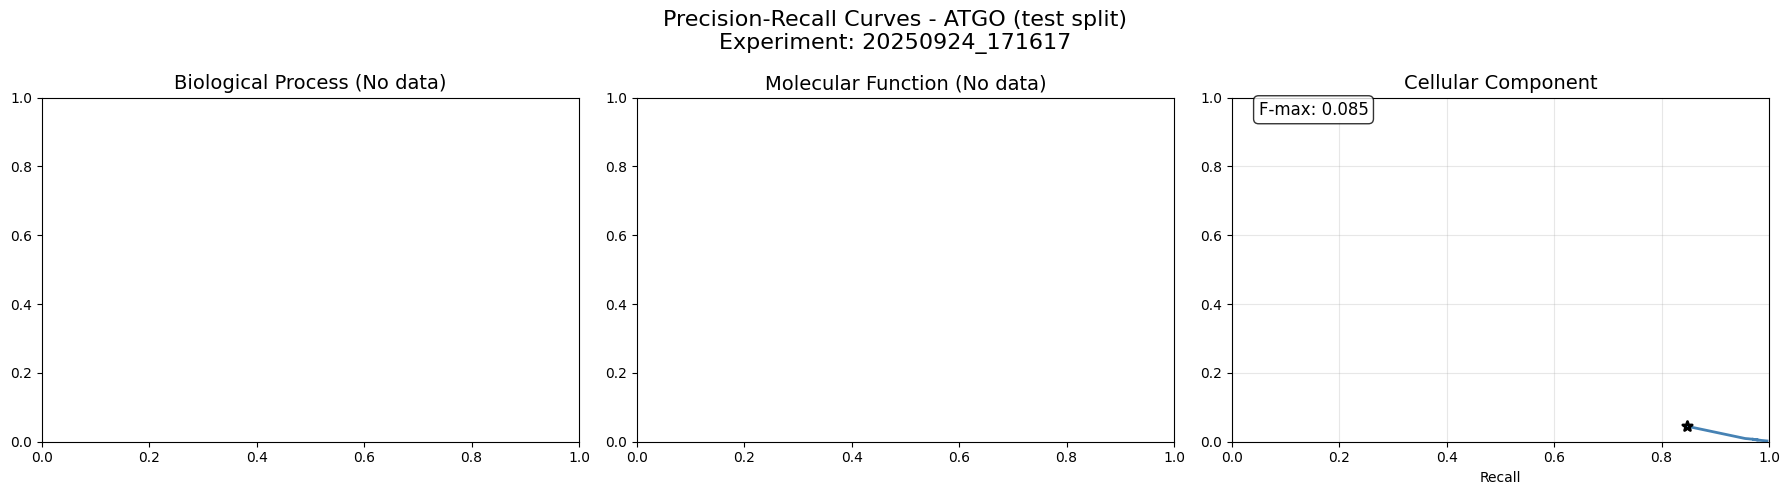

In [10]:
plot_pr_curves("ATGO", split="test", qualifier=None, show_fmax=True)

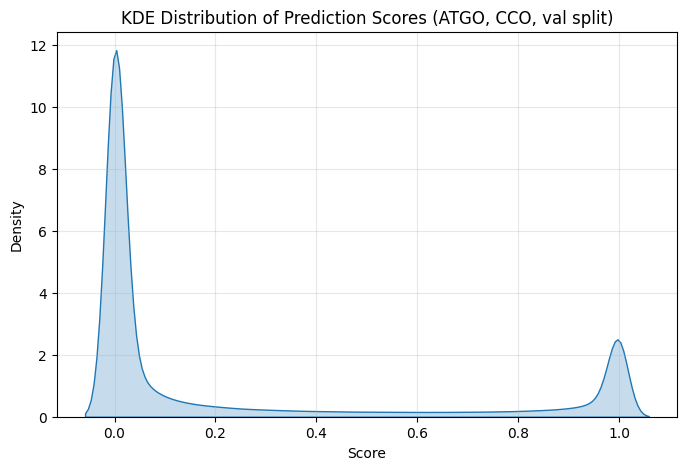

In [11]:
# Load validation predictions for ATGO CCO
val_predictions = pd.read_csv(
    exp_dir / "predictions" / "predictions_test_CCO.tsv", sep='\t'
)

# Plot KDE distribution of scores
plt.figure(figsize=(8, 5))
sns.kdeplot(val_predictions['score'], fill=True)
plt.title('KDE Distribution of Prediction Scores (ATGO, CCO, val split)')
plt.xlabel('Score')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.show()

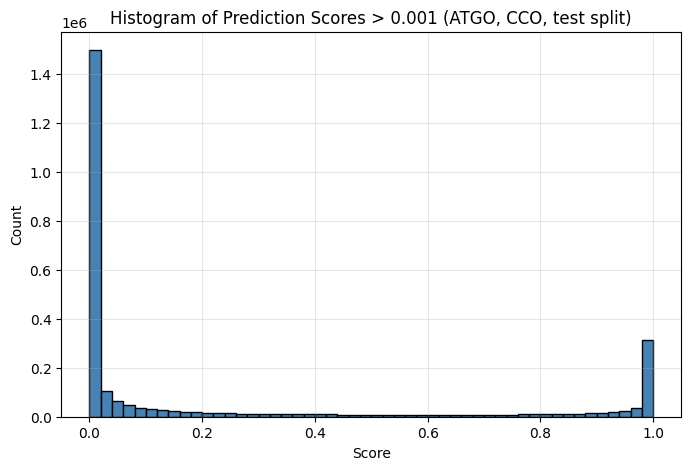

In [15]:
# Plot histogram of prediction scores > 0.001
plt.figure(figsize=(8, 5))
filtered_scores = predictions[predictions['score'] > 0.000]['score']
plt.hist(filtered_scores, bins=50, color='steelblue', edgecolor='black')
plt.title('Histogram of Prediction Scores > 0.001 (ATGO, CCO, test split)')
plt.xlabel('Score')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Define root terms for each subontology
root_terms = {
    "BPO": "GO:0008150",
    "MFO": "GO:0003674",
    "CCO": "GO:0005575"
}

mean_scores = {}
for subontology, root_term in root_terms.items():
    # Filter predictions for the root term
    root_pred = predictions[predictions['term_ID'] == root_term]
    if not root_pred.empty:
        mean_score = root_pred['score'].mean()
        mean_scores[subontology] = mean_score
        print(f"{subontology} root term ({root_term}) mean score: {mean_score:.6f}")
    else:
        print(f"{subontology} root term ({root_term}) not present in predictions.")

mean_scores

BPO root term (GO:0008150) not present in predictions.
MFO root term (GO:0003674) not present in predictions.
CCO root term (GO:0005575) mean score: 0.999763


{'CCO': 0.9997634661361524}